In [13]:
from langgraph.graph import StateGraph, START, END,add_messages
from langchain_groq import ChatGroq
from typing import TypedDict, Literal,Annotated
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage,BaseMessage
from dotenv import load_dotenv
from pydantic import BaseModel, Field
#from langgraph.graph.messages import add_messages

In [14]:
model = ChatGroq(model="llama-3.1-8b-instant", temperature=0.7)

In [15]:
class chatstate(TypedDict):

    """ 
    Basemessage is the base class for all message types in LangChain, including SystemMessage, HumanMessage, and AIMessage.So the messages field can contain a list of any of these message types, allowing for a flexible conversation history that can include system instructions, user inputs, and AI responses.
    """
    messages:Annotated[list[BaseMessage],add_messages, Field(description="The conversation history, including system, human, and AI messages.")]

In [16]:
def chatbot(state:chatstate):
    # take the user query 
    user_query=state["messages"]
    #invoke the model with the conversation history
    response=model.invoke(user_query)
    # add the model response to the conversation history
    return {"messages":[response]}

In [17]:
from langgraph.checkpoint.memory import InMemorySaver


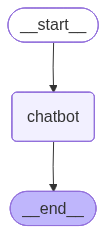

In [18]:
checkpoint=InMemorySaver() # create a checkpoint to save the conversation history in memory

graph=StateGraph(chatstate)

graph.add_node("chatbot",chatbot)
graph.add_edge(START,"chatbot")
graph.add_edge("chatbot",END)
workflow=graph.compile(checkpointer=checkpoint)# compile the graph and save the conversation history in memory
workflow

In [19]:
intial_state={"messages":[HumanMessage(content="what is climate change?")]}
workflow.invoke(intial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
"""
The problem this approach is doesn't have memory of the conversation history, so each time we invoke the model, we need to provide the entire conversation history as input. This can be inefficient and may lead to performance issues as the conversation grows longer. Additionally, it may not be able to maintain context effectively across multiple interactions, which can result in less coherent responses from the model. Here comes the term persistent in langgraph, which allows us to maintain state across multiple invocations of the workflow, enabling the model to have memory of the conversation history and maintain context effectively.
"""

while True:
    user_query=input("User:")
    
    if user_query.lower() in ["exit","quit"]:
        break
    response= workflow.invoke({"messages":[HumanMessage(content=user_query)]})

    print("AI:",response['messages'][-1].content)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [21]:
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver


# Chatbot with persistent state
thread_id = "1"  # Unique identifier for the conversation thread

while True:
    user_query = input("User: ")

    if user_query.lower() in ["exit", "quit"]:
        break

    # Construct the config payload containing the unique thread target
    config = {"configurable": {"thread_id": thread_id}}

    # Execute utilizing the compiled app object
    response = workflow.invoke(
        {"messages": [HumanMessage(content=user_query)]},
        config=config,
    )

    # Output the last message added to the state
    print("AI:", response["messages"][-1].content)


AI: Nice to meet you, Manisj. Is there something I can help you with or would you like to chat?
AI: I'm not able to access any information about you or your personal details, including your name. Our conversation has just started, and I'm here to help answer any questions you may have. If you'd like to share your name with me, I can use it to make our conversation more personalized, but it's completely up to you.
AI: It seems like you forgot to ask a question or provide some information. How can I assist you today?
AI: Is there something I can help you with?
